# 02a — Naive Bayes (Person A)

**Goal**: Train a Multinomial Naive Bayes classifier with hyperparameter tuning, then evaluate on the test set.

**Author**: Person A

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, auc, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print("Imports OK")

Imports OK


## 2. Load Preprocessed Data

In [2]:
X_train = joblib.load('../data/X_train_tfidf.pkl')
X_test  = joblib.load('../data/X_test_tfidf.pkl')
y_train = joblib.load('../data/y_train.pkl')
y_test  = joblib.load('../data/y_test.pkl')
tfidf   = joblib.load('../data/tfidf_vectorizer.pkl')
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4459, 3000), Test: (1115, 3000)


## 3. Hyperparameter Tuning with GridSearchCV

In [3]:
param_grid = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 5.0],
    'fit_prior': [True, False]
}

grid = GridSearchCV(
    MultinomialNB(),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)

print(f"Best params: {grid.best_params_}")
print(f"Best CV F1:  {grid.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'alpha': 0.1, 'fit_prior': True}
Best CV F1:  0.9219


## 4. Evaluate on Test Set

In [4]:
best_nb = grid.best_estimator_
y_pred = best_nb.predict(X_test)
y_proba = best_nb.predict_proba(X_test)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_proba)

metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Score':  [accuracy, precision, recall, f1, roc_auc]
})
print("\n=== Metrics ===")
print(metrics.to_string(index=False))

=== Classification Report ===
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.98      0.87      0.92       149

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115


=== Metrics ===
   Metric    Score
 Accuracy 0.979372
Precision 0.977273
   Recall 0.865772
 F1-Score 0.918149
  ROC-AUC 0.984146


## 5. Confusion Matrix

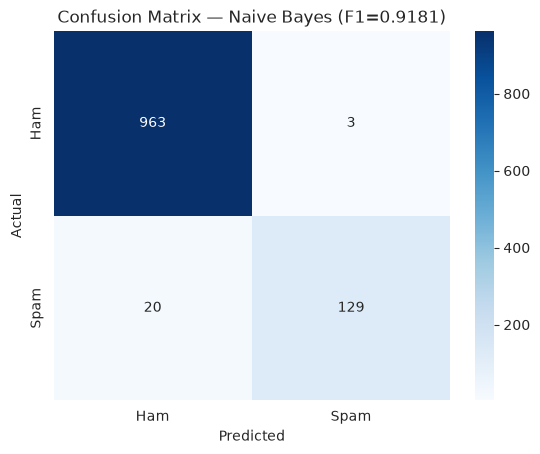

In [5]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title(f'Confusion Matrix — Naive Bayes (F1={f1:.4f})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 6. ROC Curve

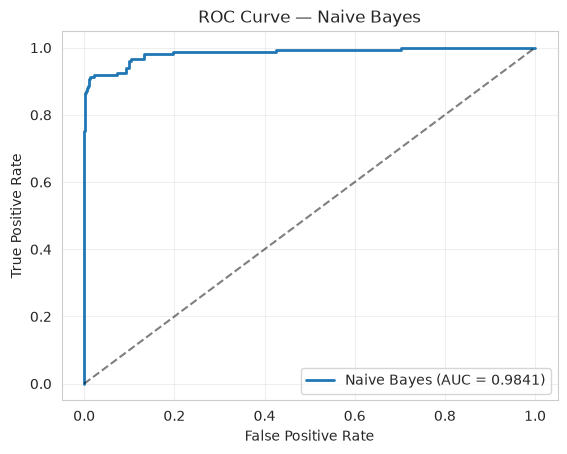

In [6]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'Naive Bayes (AUC = {roc_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Naive Bayes')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

## 7. Save Model & Metrics

In [7]:
joblib.dump(best_nb, '../data/model_nb.pkl')
joblib.dump({'y_pred': y_pred, 'y_proba': y_proba,
             'accuracy': accuracy, 'precision': precision,
             'recall': recall, 'f1': f1, 'roc_auc': roc_auc},
            '../data/metrics_nb.pkl')
print("Model and metrics saved")

Model and metrics saved
